In [55]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/mnt/home/nghosh/lora/lora_playground/plot_utils.py:208: UserWarning: OPTIM_COLORS entries with no OPTIM_FAMILIES membership (plots filtering by family will silently drop them): ['adam-muon-lora']. Add to a family in plot_utils.py or accept the exclusion.
  _validate_family_membership()


In [56]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lora_playground.plot_utils import (
    DIVERGE_THRESHOLD, OPTIM_COLORS, OPTIM_FAMILIES, OPTIM_MARKERS,
    has_runs, max_loss, parse_flag, best_run,
    plot_leaderboard_by_rank, standard_sweep_figure,
    LEADERBOARD_OPTIMIZERS, LEADERBOARD_DEFAULTS, ADAMW_WORKLOAD_SIGMA,
    parent_label, is_default_hp, tuned_suffix,
    eval_at_step, aggregate_by_seed, prefer_finer_eval,
)
from lora_playground.loader import load_runs, inventory_runs, render_inventory

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

# Notebook-level horizon and rank policy. The 8k notebook is a clone with
# NOTEBOOK_HORIZON = 8000.
#
# NOTEBOOK_HORIZON pins the comparison cell: only runs trained with
# max_steps == NOTEBOOK_HORIZON appear here. This keeps every leaderboard
# row apples-to-apples within the horizon's LR schedule. A run extended
# from 2k to 8k is a different (schedule, horizon) workload and lives in
# the other notebook.
NOTEBOOK_HORIZON = 2000
MIN_RANK = 16


def filter_min_rank(runs):
    """Drop runs with lora_r < MIN_RANK so panels stay in the regime of interest."""
    return [(c, e) for c, e in runs if int(c.get("lora_r", 16)) >= MIN_RANK]


In [57]:
# Single source of truth for "what could be silently wrong" — orphans,
# self-deprecated groups, optimizers in logs but missing from OPTIM_COLORS,
# and (optimizer, rank, mult) cells whose best lr is at the swept boundary.
print(render_inventory(inventory_runs("../logs")))

Loaded 141 of 144 groups on disk.

UNKNOWN OPTIMIZERS (3) — in logs but missing from OPTIM_COLORS, will be dropped by any cell that filters on it:
  kfac-lora
  svd-cumulative-adamw
  svd-step-adamw

Coverage: 108 (optimizer, rank, mult) cells
PINNED at lr-range boundary (43) — extension sweep recommended:
  adam-clip-product-lora            r=16          best_lr=3e-04 (final=0.7555)   swept=['3e-04', '1e-03'] → pinned_low
  adam-clip-product-lora            r=64          best_lr=3e-04 (final=0.7447)   swept=['3e-04', '1e-03'] → pinned_low
  adam-clip-product-lora-coupled-endrms  r=16          best_lr=3e-04 (final=0.7604)   swept=['3e-04', '1e-03'] → pinned_low
  adam-clip-product-lora-coupled-endrms  r=64          best_lr=3e-04 (final=0.7423)   swept=['3e-04', '1e-03'] → pinned_low
  adam-lin-lora                     r=2           best_lr=1e-03 (final=0.7914)   swept=['3e-04', '1e-03'] → pinned_high
  adam-lin-lora                     r=4           best_lr=1e-03 (final=0.7782)   swept

In [58]:
# Section-specific palettes (general OPTIM_COLORS imported from library).
M_COLORS = {1: plt.cm.plasma(0.15), 4: plt.cm.plasma(0.50), 16: plt.cm.plasma(0.85)}
MODE_COLORS = {"svd_step_oracle": "#ff7f0e", "svd_cumulative_oracle": "#2ca02c"}

# Convention: same color per base optimizer across all m. m differentiation
# happens via MUON_VARIANT_MARKERS, not color. This keeps families visually
# consistent across the leaderboard and the muon-variants panel.
MUON_VARIANT_COLORS = {
    "muon":              OPTIM_COLORS["muon-lora"],
    "muon+m=4":          OPTIM_COLORS["muon-lora"],
    "muon+m=16":         OPTIM_COLORS["muon-lora"],
    "muon+ns=0":         "#bababa",  # ns=0 is a sanity-check variant, distinct
    "product-muon":      OPTIM_COLORS["product-muon-lora"],
    "product-muon+m=4":  OPTIM_COLORS["product-muon-lora"],
    "adam-muon":         OPTIM_COLORS["adam-muon-lora"],
    "adam-muon+m=4":     OPTIM_COLORS["adam-muon-lora"],
}

MUON_VARIANT_MARKERS = {
    "muon":              "o",
    "muon+m=4":          "D",
    "muon+m=16":         "P",
    "muon+ns=0":         "x",
    "product-muon":      "o",
    "product-muon+m=4":  "D",
    "adam-muon":         "o",   # base marker, matches OPTIM_MARKERS convention
    "adam-muon+m=4":     "D",
}

MUON_VARIANT_LINESTYLES = {
    "muon":              "-",                    # m=1 solid
    "muon+m=4":          (0, (5, 2)),              # m=4 long-dash
    "muon+m=16":         (0, (1, 2)),              # m=16 dotted
    "muon+ns=0":         (0, (3, 2, 1, 2)),        # ns=0 dash-dot
    "product-muon":      "-",
    "product-muon+m=4":  (0, (5, 2)),
    "adam-muon":         "-",
    "adam-muon+m=4":     (0, (5, 2)),
}

## Optimizer comparison by family

Each family panel tests a specific composition class against AdamW. Uninformative low-performers (no-Adam baselines, per-coord K-FAC family, GaLore, unfixed `*-post`) are dropped — they're consistently 0.03+ above AdamW per the synthesis, and clutter the visual without adding signal.

All numbers are single-seed at the canonical 2k-step horizon; multi-seed verification is deferred. Δ values describe the single seed measured, not seed-to-seed significance.

/tmp/ipykernel_525067/3440583009.py:20: UserWarning: load_runs returned runs from 23 commits: d43e04a (58 runs), f7fe365 (41 runs), 7af625f (23 runs), 0403ea6 (19 runs), a2a5dbf (17 runs), c7f8256 (14 runs), 21cb74b (13 runs), 6f615a8 (12 runs), a4997e4 (10 runs), 27d05f0 (10 runs), 8a7a6be (9 runs), 5b3e8cd (8 runs), 5498ba3 (7 runs), 3ce7844 (6 runs), 4928028 (6 runs), ea6801e (6 runs), 2f3122b (4 runs), 7c1ffdb (4 runs), 1addd5f (3 runs), 64052e8 (2 runs), 6ae1ec7 (2 runs), 9ab6a85 (2 runs), 22d6e9f (1 run). Behavior at default settings can differ across commits; if comparing absolute losses, verify the relevant defaults in HARDCODED_DEFAULT_HISTORY or pin the comparison to a single commit. Pass warn_cross_commit=False to silence.
  ext_runs = load_runs(


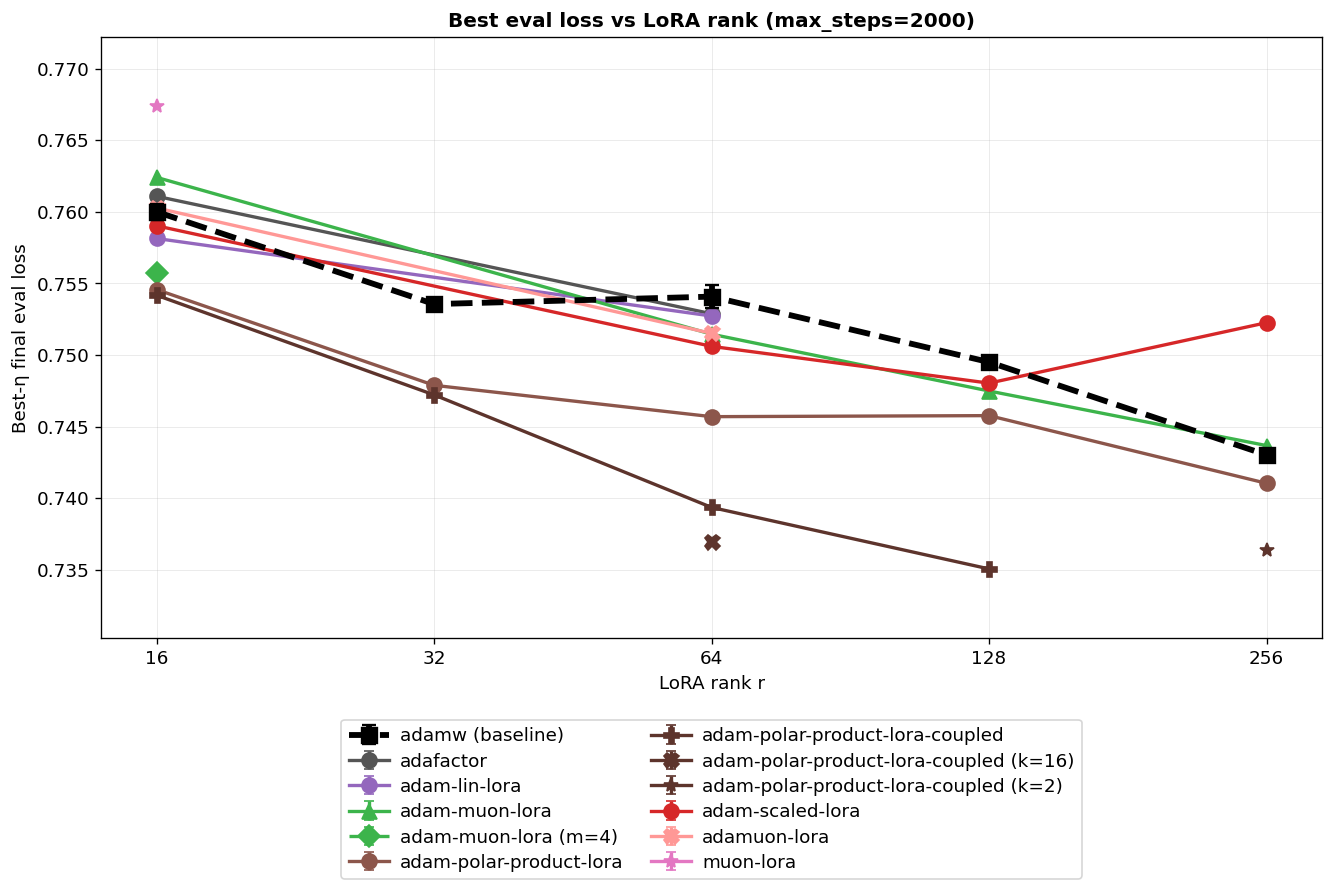


Leaderboard at max_steps=2000 (mean ± std across seeds)
  r= 16  adam-polar-product-lora-coupled                     0.7542  (n_seed=1, η=3e-04)
  r= 16  adam-polar-product-lora                             0.7546  (n_seed=1, η=3e-04)
  r= 16  adam-muon-lora (m=4)                                0.7557  (n_seed=1, η=3e-03)
  r= 16  adam-lin-lora                                       0.7581  (n_seed=1, η=1e-03)
  r= 16  adam-scaled-lora                                    0.7590  (n_seed=1, η=1e-03)
  r= 16  adamw                                               0.7600 ± 0.0005  (n_seed=5, η=3e-04)
  r= 16  adamuon-lora                                        0.7603  (n_seed=1, η=3e-04)
  r= 16  adafactor                                           0.7611  (n_seed=1, η=3e-04)
  r= 16  adam-muon-lora                                      0.7624  (n_seed=1, η=3e-03)
  r= 16  muon-lora                                           0.7674  (n_seed=1, η=1e-03)
  r= 32  adam-polar-product-lora-coupled    

In [59]:
# Leaderboard: Bucket A optimizers only, max_steps == NOTEBOOK_HORIZON
# (apples-to-apples within the horizon's LR schedule). For each (parent, r)
# we emit a "default" row (parent's default HP) and a "best-tuned" row (best
# HP that differs from default) when one exists and beats default.
# See docs/notes/optimizer_triage.md for the curated set.
import re

RENAME_ALIAS = {"psi-lora": "diag-scaled-lora", "kfac-lora": "kron-grad-lora"}
NEW_PSI_GROUPS = {"psi_lora_2k"}


def _alias(c, group):
    c["_lora_r"] = int(c.get("lora_r", 16))
    if group not in NEW_PSI_GROUPS:
        c["optimizer"] = RENAME_ALIAS.get(c["optimizer"], c["optimizer"])


# Pin the comparison horizon: only runs trained with max_steps == NOTEBOOK_HORIZON
# appear here. Cross-horizon comparison lives in the other notebook.
ext_runs = load_runs(
    where={"optimizer": LEADERBOARD_OPTIMIZERS, "max_steps": NOTEBOOK_HORIZON},
    cfg_postprocess=_alias,
    logs_root="../logs",
)
ext_runs = filter_min_rank(ext_runs)

# When both a native run and a salvaged-from-longer-horizon run exist for
# the same algorithmic cell, prefer the one with finer eval cadence (more
# points on training-curve panels). The salvage path inherits the source's
# eval_every (often coarser).
def _cell_key(cfg):
    derived = cfg.get("_derived", {})
    return (
        cfg["optimizer"],
        float(cfg["lr"]),
        int(cfg.get("lora_r", 16)),
        float(cfg.get("lora_plus_multiplier", 1.0)),
        int(cfg.get("seed", 0)),
        derived.get("effective_picard_iters", cfg.get("picard_iters_override")),
        cfg.get("ns_iters"),
    )

ext_runs = prefer_finer_eval(ext_runs, key_fn=_cell_key)


def _key(cfg):
    """Group key for seed aggregation: parent label, rank, m, all HP fields
    that vary across the family (so the aggregator picks best-η per cell)."""
    parent = parent_label(cfg["optimizer"])
    m = float(cfg.get("lora_plus_multiplier", 1.0))
    derived = cfg.get("_derived", {})
    pic = derived.get("effective_picard_iters", cfg.get("picard_iters_override"))
    nsi = cfg.get("ns_iters")
    return (parent, cfg["_lora_r"], m, pic, nsi)


# aggregate_by_seed picks best-η per seed (within the same group key) at
# NOTEBOOK_HORIZON, then computes mean/std across seeds.
agg = aggregate_by_seed(ext_runs, target_step=NOTEBOOK_HORIZON, key_fn=_key)


# For each (parent, r): split agg into "default-HP" cells (matching parent
# defaults across all axes including m) and "tuned" cells (any axis differs).
# Pick best mean of each group → at most one default row + one tuned row.
def _is_default_cell(parent, cfg):
    return is_default_hp(parent, cfg)


by_parent_rank: dict = {}
for key, entry in agg.items():
    parent, r = key[0], key[1]
    by_parent_rank.setdefault((parent, r), []).append((key, entry))


best: dict = {}
yerr_map: dict = {}
seed_counts: dict = {}

for (parent, r), entries in by_parent_rank.items():
    default_entries = [(k, e) for k, e in entries if _is_default_cell(parent, e["best_cfg"])]
    tuned_entries   = [(k, e) for k, e in entries if not _is_default_cell(parent, e["best_cfg"])]

    # Default row: best-mean default-HP cell (or fall back to overall best
    # if no default-HP run exists at this rank).
    if default_entries:
        _, def_entry = min(default_entries, key=lambda x: x[1]["mean"])
        label = parent
        best[(label, r)] = (def_entry["best_cfg"], def_entry["best_evs"], def_entry["mean"])
        seed_counts[(label, r)] = def_entry["n"]
        if def_entry["std"] == def_entry["std"]:
            yerr_map[(label, r)] = def_entry["std"]
    else:
        def_entry = None

    # Tuned row: best-mean non-default cell. Skip if no tuned data, or if
    # tuned mean is not better than default (so the user only sees a tuned
    # row when it's actually a useful alternative).
    if tuned_entries:
        _, tun_entry = min(tuned_entries, key=lambda x: x[1]["mean"])
        if def_entry is None or tun_entry["mean"] < def_entry["mean"]:
            label = parent + tuned_suffix(parent, tun_entry["best_cfg"])
            best[(label, r)] = (tun_entry["best_cfg"], tun_entry["best_evs"], tun_entry["mean"])
            seed_counts[(label, r)] = tun_entry["n"]
            if tun_entry["std"] == tun_entry["std"]:
                yerr_map[(label, r)] = tun_entry["std"]


# Color/marker/linestyle: same color per parent across all m; m differentiation via
# marker, m+linestyle for visual distinction.
def _base(label):
    return label.split(" (")[0]


_M_MARKERS = {4: "D", 16: "P", 32: "X"}
_M_LINESTYLES = {1: "-", 4: (0, (5, 2)), 16: (0, (1, 2)), 32: (0, (3, 2, 1, 2))}

_color_map: dict = {}
_marker_map: dict = {}
_linestyle_map: dict = {}
# Marker pool used to disambiguate tuned rows that would otherwise share
# style with their default sibling (same color, same m → same marker).
_TUNED_MARKER_POOL = ["P", "X", "*", "v", "^", "<", ">", "h"]
for (lab, _) in best:
    base_opt = _base(lab)
    _color_map[lab] = OPTIM_COLORS.get(base_opt, "grey")
    m_match = re.search(r"m=(\d+)", lab)
    m = int(m_match.group(1)) if m_match else 1
    if m_match:
        _marker_map[lab] = _M_MARKERS.get(m, "*")
    else:
        _marker_map[lab] = OPTIM_MARKERS.get(base_opt, "o")
    _linestyle_map[lab] = _M_LINESTYLES.get(m, "-")
_color_map["adamw"] = OPTIM_COLORS["adamw"]

# Disambiguate tuned rows that share (color, marker, linestyle) with their
# default-row sibling. Walk labels in stable order; for each collision, pick
# the next unused marker from the pool.
def _style_key(lab):
    return (_color_map[lab], _marker_map[lab], _linestyle_map[lab])


seen_styles: set = set()
for lab in sorted({l for l, _ in best}):
    k = _style_key(lab)
    if k in seen_styles:
        # Collision: perturb marker until distinct.
        for cand in _TUNED_MARKER_POOL:
            _marker_map[lab] = cand
            if _style_key(lab) not in seen_styles:
                break
    seen_styles.add(_style_key(lab))

# Hard assertion: no two leaderboard rows may share style. Fail loud rather
# than silently render two identical legend entries.
_styles_per_label = {lab: _style_key(lab) for lab, _ in best}
_dup_styles = [s for s in _styles_per_label.values() if list(_styles_per_label.values()).count(s) > 1]
assert not _dup_styles, f"leaderboard style collision: {[lab for lab, s in _styles_per_label.items() if s in _dup_styles]}"

plot_leaderboard_by_rank(
    best, baseline_optimizer="adamw",
    color_map=_color_map, marker_map=_marker_map, linestyle_map=_linestyle_map,
    yerr_map=yerr_map,
    suptitle=f"Best eval loss vs LoRA rank (max_steps={NOTEBOOK_HORIZON})",
)
plt.show()

# Print the same data as a table.
print(f"\nLeaderboard at max_steps={NOTEBOOK_HORIZON} (mean \u00b1 std across seeds)")
for (lab, r) in sorted(best, key=lambda k: (k[1], best[k][2])):
    cfg, evs, fl = best[(lab, r)]
    err = yerr_map.get((lab, r), float("nan"))
    n = seed_counts.get((lab, r), 1)
    err_str = f" \u00b1 {err:.4f}" if err == err else ""
    print(f"  r={r:3d}  {lab:50s}  {fl:.4f}{err_str}  (n_seed={n}, \u03b7={cfg['lr']:.0e})")


In [60]:
# all_runs: AdamW + comprehensive baseline data at MIN_RANK, used as the
# reference overlay for the LoRA+ co-sweep panel.
RENAME_ALIAS = {"psi-lora": "diag-scaled-lora", "kfac-lora": "kron-grad-lora"}
NEW_PSI_GROUPS = {"psi_lora_2k"}


def _alias_optimizer(cfg, group):
    if group not in NEW_PSI_GROUPS:
        cfg["optimizer"] = RENAME_ALIAS.get(cfg["optimizer"], cfg["optimizer"])


all_runs = load_runs(
    where={"optimizer": list(OPTIM_COLORS), "lora_r": MIN_RANK,
           "lora_plus_multiplier": 1.0, "max_steps": NOTEBOOK_HORIZON},
    cfg_postprocess=_alias_optimizer,
    logs_root="../logs",
)
print(f"all_runs (r={MIN_RANK} reference overlay): {len(all_runs)} runs across "
      f"{len({c['optimizer'] for c, _ in all_runs})} optimizers")


all_runs (r=16 reference overlay): 252 runs across 42 optimizers


/tmp/ipykernel_525067/3707530088.py:12: UserWarning: load_runs returned runs from 29 commits: d43e04a (71 runs), 21cb74b (32 runs), a5ef990 (14 runs), ea6801e (14 runs), f7fe365 (9 runs), 0403ea6 (9 runs), f031dce (8 runs), bb7d6d2 (8 runs), f8b96ce (8 runs), 4928028 (8 runs), ac81bba (8 runs), 6f615a8 (6 runs), a1e5f41 (6 runs), c7f8256 (5 runs), 9f33448 (4 runs), f8dbfe2 (4 runs), 87303df (4 runs), 6ae1ec7 (4 runs), 5498ba3 (4 runs), 16840b6 (4 runs), 7c1ffdb (4 runs), a4997e4 (4 runs), 27d05f0 (4 runs), dc200e7 (2 runs), 8a7a6be (2 runs), 22d6e9f (2 runs), 9ab6a85 (2 runs), 64052e8 (1 run), acafd45 (1 run). Behavior at default settings can differ across commits; if comparing absolute losses, verify the relevant defaults in HARDCODED_DEFAULT_HISTORY or pin the comparison to a single commit. Pass warn_cross_commit=False to silence.
  all_runs = load_runs(


### Adam → spectral/polar (the headline)

  [filtered diverged] adam-polar-product-lora η=1e-02 max=1.977 final=1.651
  [filtered diverged] adamw η=1e-02            max=9.009 final=6.937
  [filtered partial from left panel] 2 run(s) below min_step=2000:
    adam-polar-product-lora η=1e-05 step=600 final-so-far=0.8379
    adam-polar-product-lora η=1e-06 step=600 final-so-far=0.9658
  [clipped from left panel y_cap=0.904] 3 run(s):
    adafactor η=3e-03 final=1.0001
    adam-polar-product-lora η=3e-03 final=0.9997
    adamw η=3e-03 final=1.0223


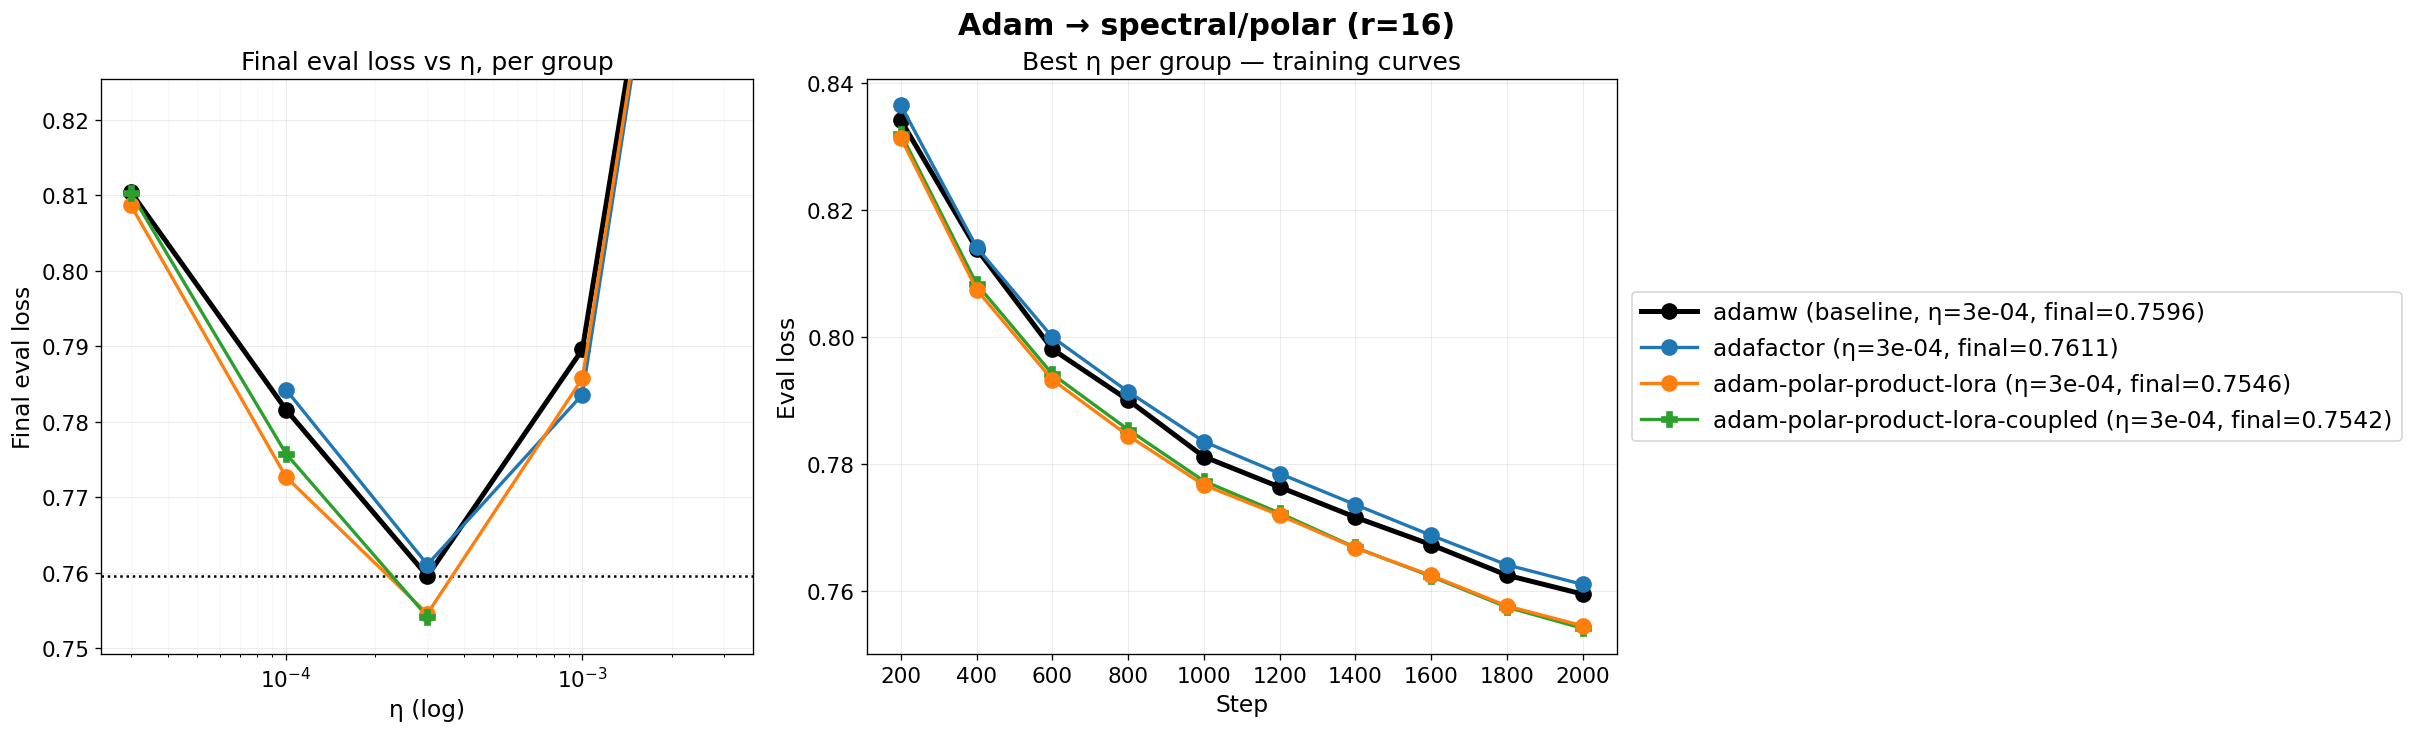

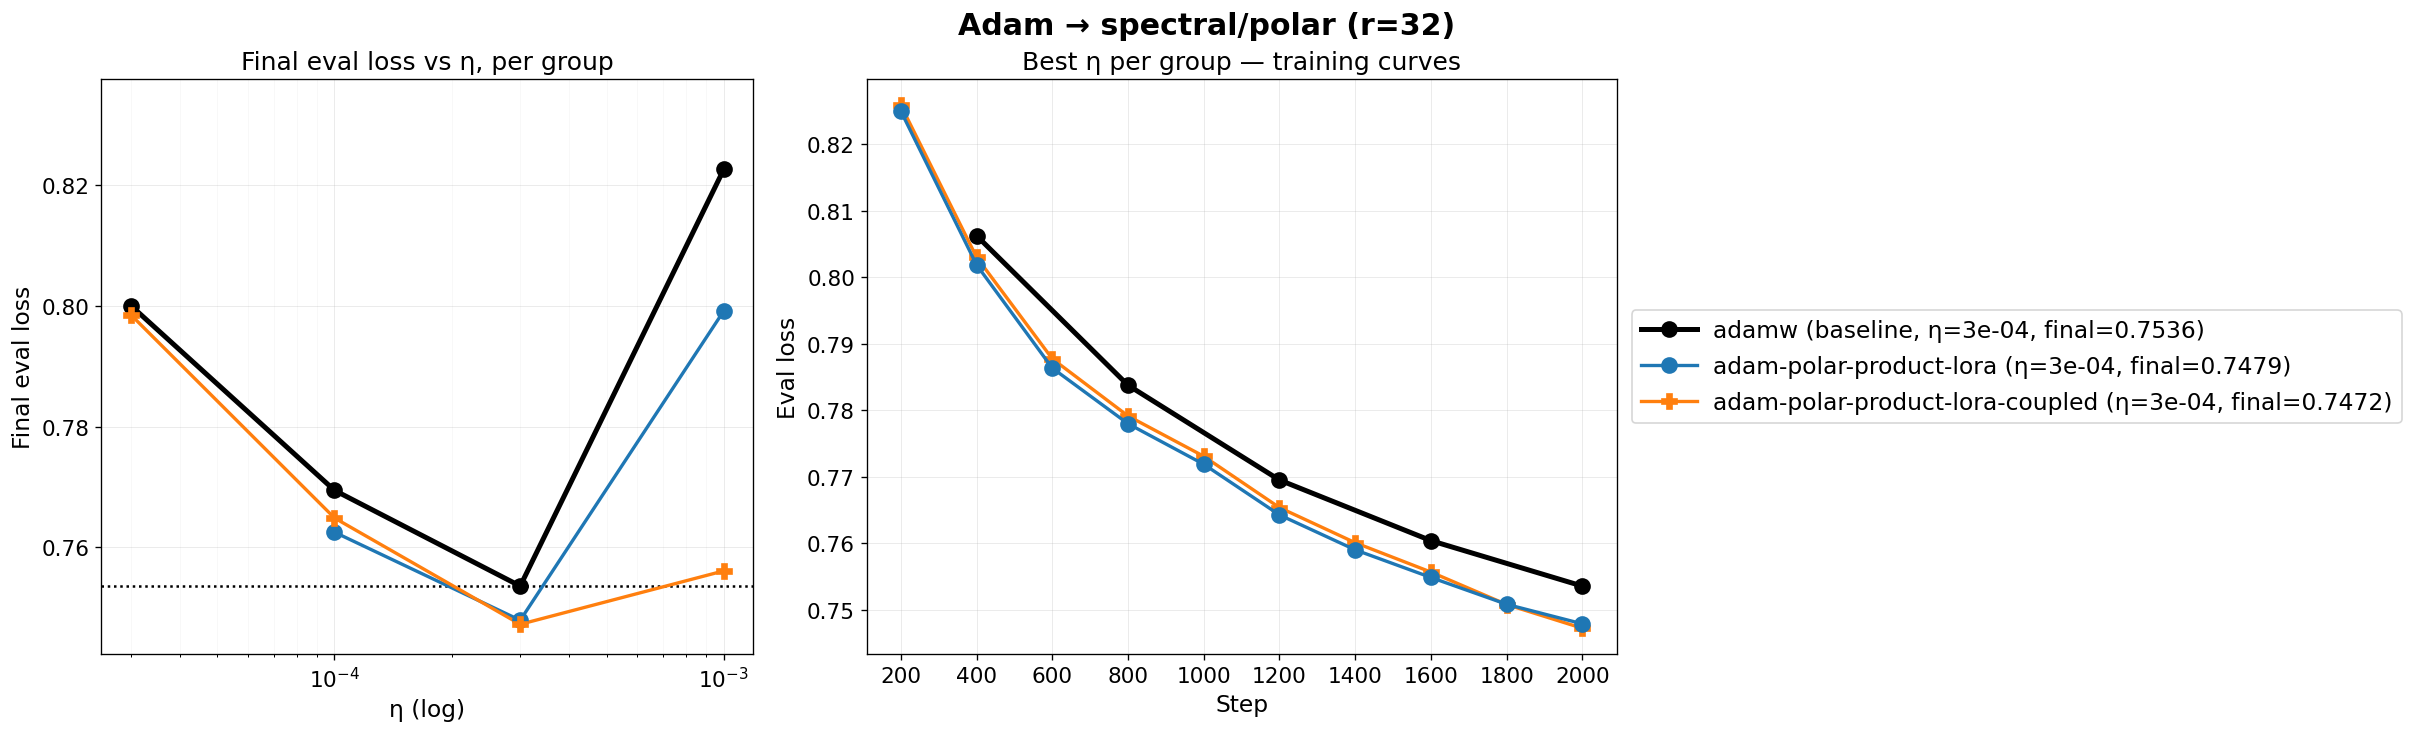

  [filtered diverged] adafactor η=3e-03        max=1.587 final=1.587
  [clipped from left panel y_cap=0.889] 1 run(s):
    adamw η=1e-03 final=0.8901


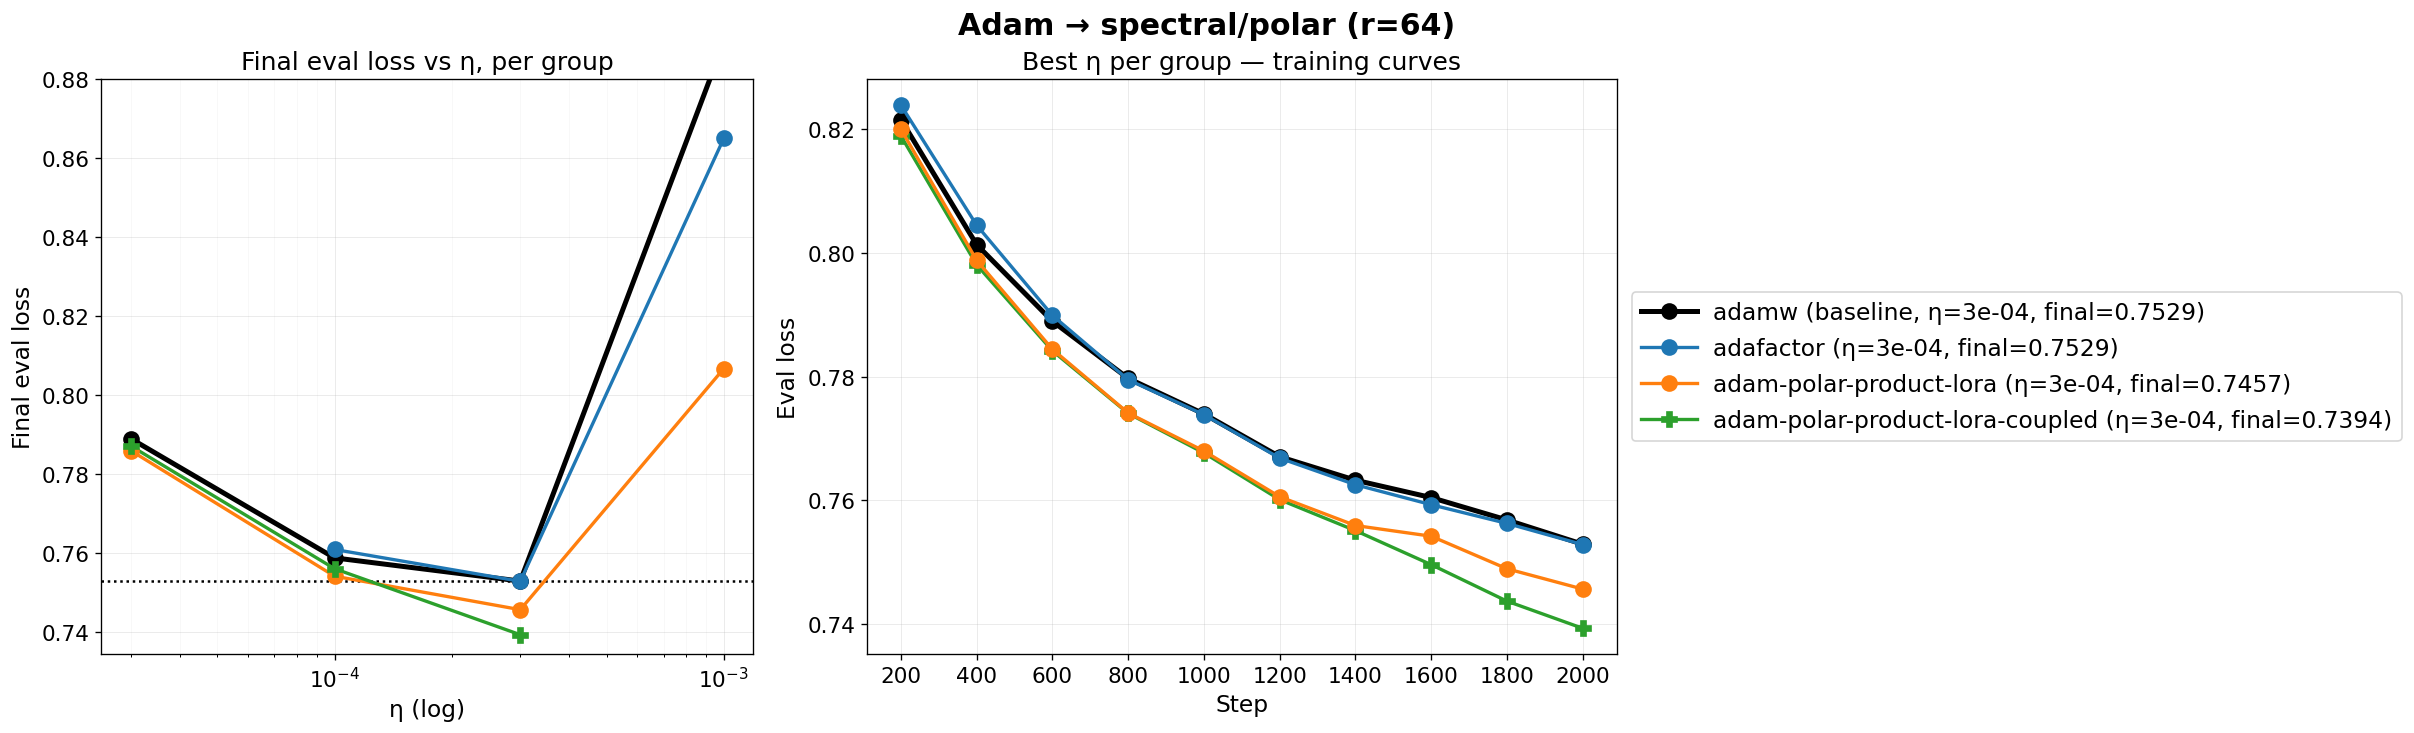

  [clipped from left panel y_cap=0.885] 1 run(s):
    adamw η=1e-03 final=1.0116


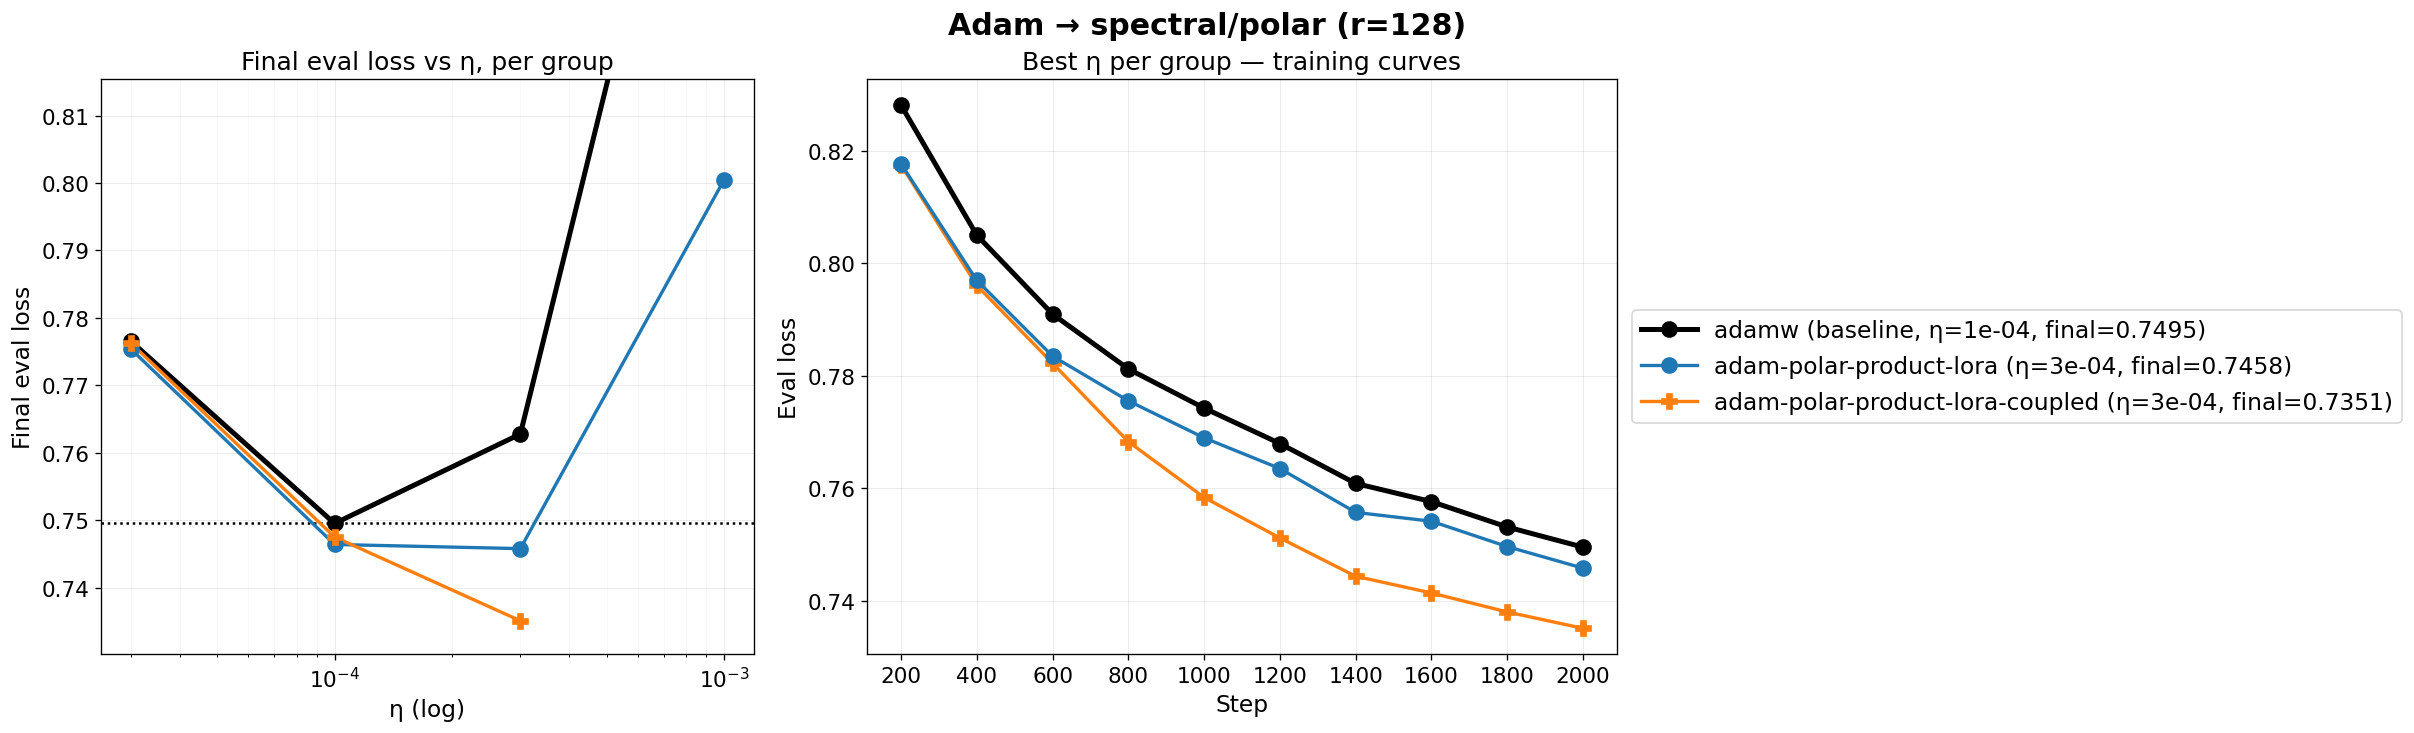

  [filtered partial from left panel] 4 run(s) below min_step=2000:
    adam-polar-product-lora η=3e-05 step=1600 final-so-far=0.7729
    adam-polar-product-lora-coupled η=1e-03 step=400 final-so-far=0.8139
    adam-polar-product-lora-coupled η=1e-04 step=400 final-so-far=0.7983
    adam-polar-product-lora-coupled η=3e-04 step=400 final-so-far=0.8019
  [clipped from left panel y_cap=0.891] 1 run(s):
    adamw η=1e-03 final=1.2023


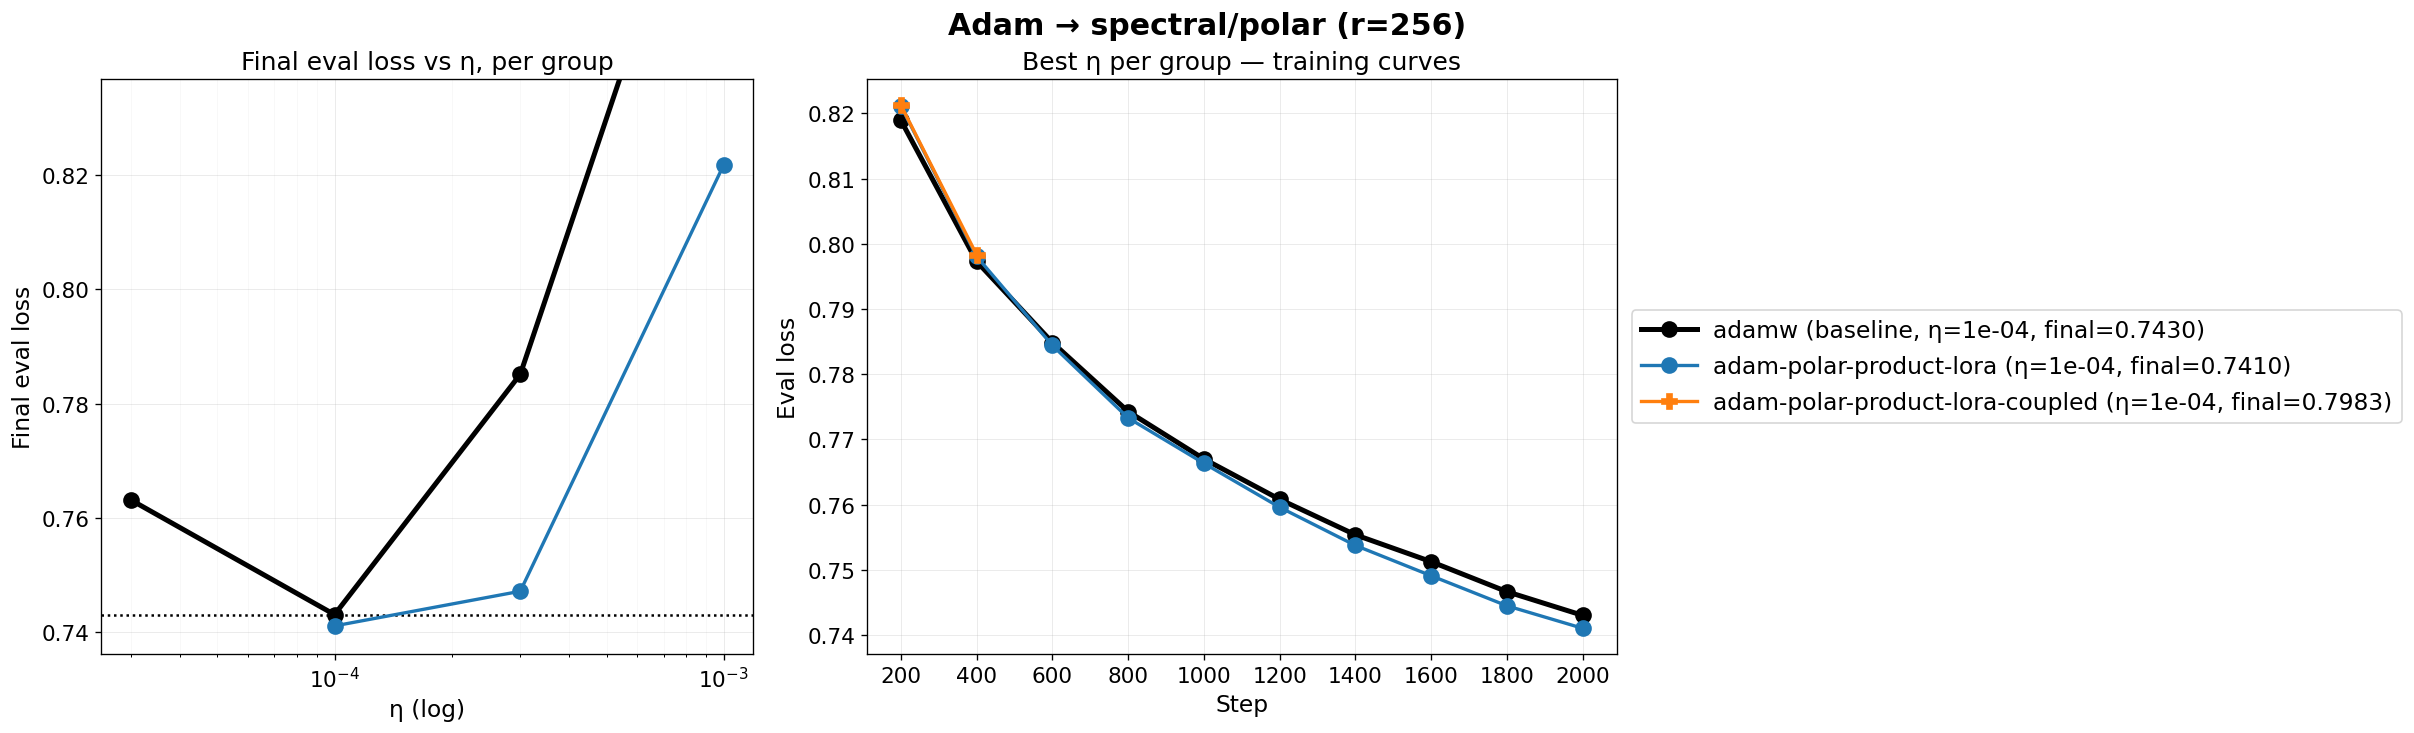

In [ ]:
# Headline panel: AdamW + Adam-polar variants. Only the parent default k
# for coupled (per LEADERBOARD_DEFAULTS) — the k-sweep belongs in its own
# panel, not here. ext_runs is already filtered to max_steps == NOTEBOOK_HORIZON
# in the leaderboard cell.
_HEADLINE = {"adamw", "adafactor", "adam-polar-product-lora", "adam-polar-product-lora-coupled"}
_K_DEFAULT = LEADERBOARD_DEFAULTS["adam-polar-product-lora-coupled"]["effective_picard_iters"]


def _on_default_hp(cfg):
    if cfg["optimizer"] != "adam-polar-product-lora-coupled":
        return True
    pic = cfg.get("_derived", {}).get("effective_picard_iters",
                                       cfg.get("picard_iters_override"))
    return pic is None or pic == _K_DEFAULT


# Restrict to ranks where AdamW (the required baseline) has data at this horizon.
_baseline_ranks = {c["_lora_r"] for c, _ in ext_runs
                   if c["optimizer"] == "adamw"
                   and float(c.get("lora_plus_multiplier", 1.0)) == 1.0}
_ranks = sorted({c["_lora_r"] for c, _ in ext_runs
                 if c["optimizer"] in _HEADLINE
                 and float(c.get("lora_plus_multiplier", 1.0)) == 1.0
                 and c["_lora_r"] >= MIN_RANK
                 and c["_lora_r"] in _baseline_ranks})

for r in _ranks:
    _runs = [(c, e) for c, e in ext_runs
             if c["_lora_r"] == r and c["optimizer"] in _HEADLINE
             and float(c.get("lora_plus_multiplier", 1.0)) == 1.0
             and _on_default_hp(c)]
    if not _runs:
        continue
    standard_sweep_figure(
        _runs,
        group_key_fn=lambda c: c["optimizer"],
        color_map=OPTIM_COLORS,
        marker_map=OPTIM_MARKERS,
        reference_runs=_runs,
        suptitle=f"Adam \u2192 spectral/polar (r={r})",
        use_global_colors=False,
        x_tick_step=max(NOTEBOOK_HORIZON // 10, 200),
    )
    plt.show()


## LoRA+ (η, m) co-sweep — AdamW, r=16, 1 epoch

In [62]:
# AdamW LoRA+ runs. Drop m=1 (== plain adamw, redundant) and m≥32 (training
# blows up at this scale).
lp_runs = load_runs(
    where={"optimizer": "adamw",
           "lora_plus_multiplier": lambda m: 1.0 < float(m) < 32.0},
    logs_root="../logs",
)
print(f'Loaded {len(lp_runs)} AdamW LoRA+ runs (m \u2208 (1, 32))')
for cfg, evs in sorted(lp_runs, key=lambda x: (x[0].get('lora_plus_multiplier', 1), x[0]['lr'])):
    print(f"  m={cfg.get('lora_plus_multiplier', 1):.0f}  "
          f"\u03b7={cfg['lr']:.0e}  final={evs[-1]['eval_loss']:.4f}")


Loaded 12 AdamW LoRA+ runs (m ∈ (1, 32))
  m=4  η=1e-05  final=0.8163
  m=4  η=3e-05  final=0.7905
  m=4  η=1e-04  final=0.7626
  m=4  η=1e-04  final=0.9891
  m=4  η=3e-04  final=0.7644
  m=4  η=3e-04  final=1.2565
  m=16  η=1e-05  final=0.7940
  m=16  η=3e-05  final=0.7684
  m=16  η=1e-04  final=0.7585
  m=16  η=1e-04  final=1.2792
  m=16  η=3e-04  final=0.8128
  m=16  η=3e-04  final=1.2171


/tmp/ipykernel_525067/4240506270.py:3: UserWarning: load_runs returned runs from 3 commits: 5b3e8cd (4 runs), ea6801e (4 runs), cf82b70 (4 runs). Behavior at default settings can differ across commits; if comparing absolute losses, verify the relevant defaults in HARDCODED_DEFAULT_HISTORY or pin the comparison to a single commit. Pass warn_cross_commit=False to silence.
  lp_runs = load_runs(


  [filtered partial from left panel] 4 run(s) below min_step=2000:
    m=16 η=1e-04                   step=1600 final-so-far=1.2792
    m=16 η=3e-04                   step=1600 final-so-far=1.2171
    m=4 η=1e-04                    step=1600 final-so-far=0.9891
    m=4 η=3e-04                    step=1600 final-so-far=1.2565


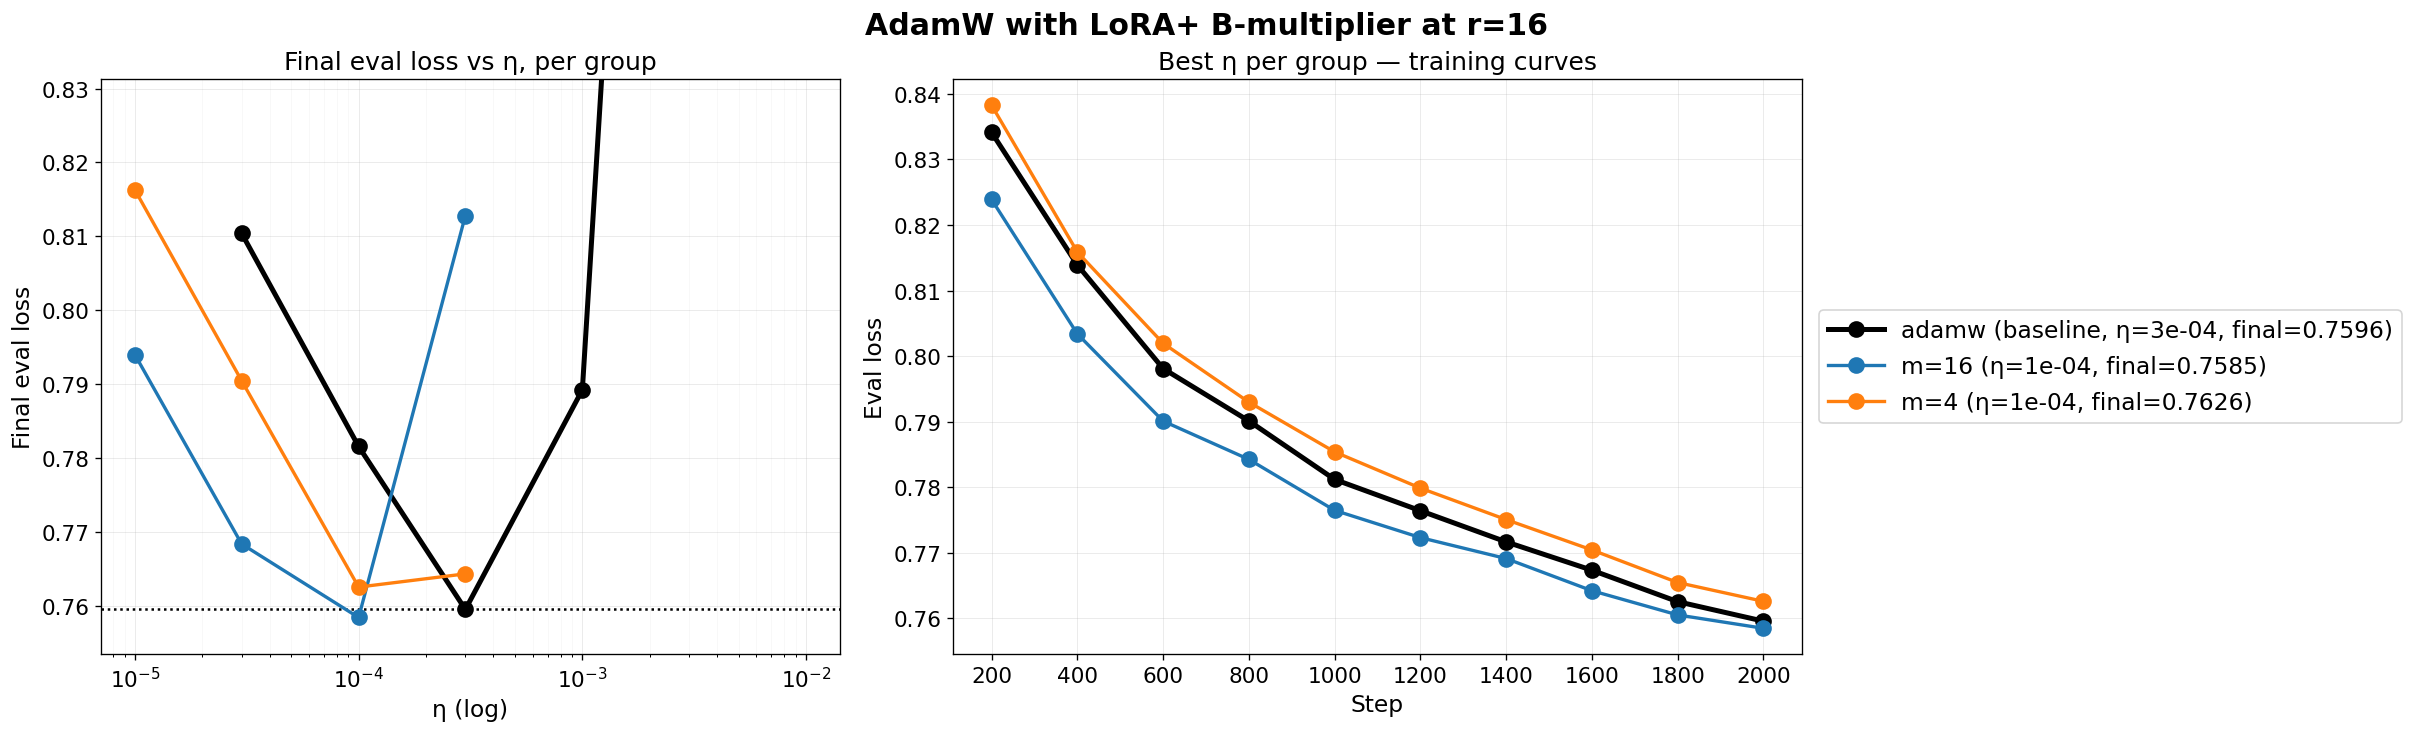

In [63]:
def _lp_group(cfg):
    return f"m={int(round(cfg.get('lora_plus_multiplier', 1.0)))}"


LP_COLOR_MAP = {f"m={m}": c for m, c in M_COLORS.items()}

standard_sweep_figure(
    lp_runs,
    group_key_fn=_lp_group,
    color_map=LP_COLOR_MAP,
    same_value_axes=(),
    reference_runs=all_runs,
    suptitle="AdamW with LoRA+ B-multiplier",
    use_global_colors=False,
)
plt.show()
